In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install -q transformers==4.20.0
!pip install -q datasets torchvision pycocotools accelerate

In [ ]:
from huggingface_hub import login
from google.colab import userdata
token = userdata.get('Nyi_token')
login(token=token)

In [ ]:
import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from pycocotools import mask as mask_utils
from transformers import MaskFormerImageProcessor, MaskFormerForInstanceSegmentation, Trainer, TrainingArguments
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [ ]:
class CocoInstanceDataset(Dataset):
    def __init__(self, annotation_file, image_root, processor):
        self.coco = COCO(annotation_file)
        self.image_root = image_root
        self.image_ids = list(self.coco.imgs.keys())
        self.processor = processor
        # Create a mapping from category ID to a continuous label index starting from 0
        categories = self.coco.loadCats(self.coco.getCatIds())
        self.cat2label = {cat['id']: i for i, cat in enumerate(categories)}
        self.label2cat = {i: cat['id'] for i, cat in enumerate(categories)} # Optional: for mapping back

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(image_id)[0]
        img_path = os.path.join(self.image_root, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        image = image.resize((800, 800), Image.BILINEAR)

        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)

        masks = []
        class_labels = []

        for ann in anns:
            # Ensure the category ID is in mapping, otherwise skip
            if ann['category_id'] not in self.cat2label:
                continue

            if isinstance(ann['segmentation'], list):  # polygon format
                rle = mask_utils.frPyObjects(ann['segmentation'], img_info['height'], img_info['width'])
                rle = mask_utils.merge(rle)
            else:
                rle = ann['segmentation']  # in case it's already RLE

            # Decode RLE and convert to boolean tensor
            mask = torch.tensor(mask_utils.decode(rle)).squeeze().bool()
            masks.append(mask)
            # Use the mapped label index
            class_labels.append(self.cat2label[ann['category_id']])

        # Ensure shape (num_instances, H, W)
        if masks:
            masks = torch.stack(masks)
        else:
            masks = torch.zeros((0, img_info['height'], img_info['width']), dtype=torch.bool)

        if masks.shape[0] > 0:
            # masks shape is (N, H, W). Interpolate requires (N, C, H, W)
            masks = masks.unsqueeze(1).float()
            masks = torch.nn.functional.interpolate(masks, size=(800, 800), mode="nearest").squeeze(1)
            masks = masks.bool()
        else:
            # Handle empty masks case with the fixed size
            masks = torch.zeros((0, 800, 800), dtype=torch.bool)

        class_labels = torch.tensor(class_labels, dtype=torch.int64)

        # Process the image. This handles resizing and normalization.
        # Note: We are NOT passing masks and class_labels to the processor here
        # as the model expects them separately after collation for training.
        encoded_inputs = self.processor(images=image, return_tensors="pt")

        # The dataset item should return the processed image data,
        # and the masks and class labels separately for the collator.
        return {
            "pixel_values": encoded_inputs["pixel_values"].squeeze(0),
            "pixel_mask": encoded_inputs["pixel_mask"].squeeze(0),
            "mask_labels": masks.float(), # Return the raw masks
            "class_labels": class_labels, # Return the raw class labels
        }

In [ ]:
# Prepare processor and model
processor = MaskFormerImageProcessor.from_pretrained("facebook/maskformer-swin-small-coco")
model = MaskFormerForInstanceSegmentation.from_pretrained("facebook/maskformer-swin-small-coco")

In [ ]:
# Load datasets (set paths accordingly)
train_dataset = CocoInstanceDataset(
    annotation_file="markerpensseg/train/_annotations.coco.json",
    image_root="markerpensseg/train",
    processor=processor
)
eval_dataset = CocoInstanceDataset(
    annotation_file="markerpensseg/valid/_annotations.coco.json",
    image_root="markerpensseg/valid",
    processor=processor
)

loading annotations into memory...
Done (t=1.91s)
creating index...
index created!
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!


In [ ]:
training_args = TrainingArguments(
    output_dir="./maskformerresults/maskformer-custom",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    fp16=True,
    report_to="none"
)

In [ ]:
# Define custom data collator
def collate_fn(samples):
    # Stack pixel values and pixel masks as these have fixed dimensions
    pixel_values = torch.stack([s["pixel_values"] for s in samples])
    pixel_mask = torch.stack([s["pixel_mask"] for s in samples])

    # Mask and class labels have variable dimensions (number of instances),
    # so they should be returned as lists of tensors
    mask_labels = [s["mask_labels"] for s in samples]
    class_labels = [s["class_labels"] for s in samples]

    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "mask_labels": mask_labels,
        "class_labels": class_labels,
    }

In [ ]:
# Train model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn,
)

trainer.train()

In [ ]:
#  [285/285 07:07, Epoch 5/5]
# Epoch	Training Loss	Validation Loss
# 1	No log	0.075703
# 2	No log	0.068235
# 3	No log	0.059542
# 4	No log	0.029000
# 5	No log	0.028160

# TrainOutput(global_step=285, training_loss=0.13086571944387335, metrics={'train_runtime': 429.5834,
# 'train_samples_per_second': 2.619, 'train_steps_per_second': 0.663, 'total_flos': 8.170823808e+17,
# 'train_loss': 0.13086571944387335, 'epoch': 5.0})

In [ ]:
sample = eval_dataset[0]
inputs = {
    k: v.unsqueeze(0).to(model.device) for k, v in sample.items() if k in ['pixel_values', 'pixel_mask']
}

with torch.no_grad():
    outputs = model(**inputs)

print(outputs)

MaskFormerForInstanceSegmentationOutput(loss=None, class_queries_logits=tensor([[[-1.8662, -2.6797, -3.2266,  ..., -1.6973, -4.8906, 13.0391],
         [-1.0566, -1.8213, -2.6660,  ..., -1.4844, -4.8828, 12.6953],
         [-1.8232, -2.8633, -3.2266,  ..., -1.2783, -4.6523, 13.2031],
         ...,
         [-1.5078, -3.3398, -3.0059,  ..., -1.2061, -4.8867, 13.2578],
         [-1.4639, -2.5918, -2.9824,  ..., -2.2559, -4.3086, 12.8047],
         [-2.2695, -2.2910, -2.4355,  ..., -0.4814, -3.4707, 12.0156]]],
       device='cuda:0'), masks_queries_logits=tensor([[[[-1.7715, -2.0859, -1.9092,  ..., -1.5039, -1.5039, -1.5049],
          [-2.5527, -2.7285, -2.3516,  ..., -1.4268, -1.3818, -1.6172],
          [-2.6445, -2.7637, -2.2773,  ..., -1.3770, -1.4658, -1.7910],
          ...,
          [-2.7539, -3.1016, -2.8555,  ..., -1.8955, -2.0820, -2.3145],
          [-2.7734, -3.2891, -3.3008,  ..., -2.6016, -2.7852, -2.7188],
          [-2.2832, -2.8105, -2.9199,  ..., -2.4395, -2.5156, -2.

In [ ]:
print("label2cat:", eval_dataset.label2cat)

label2cat: {0: 0, 1: 1}


In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import pycocotools.mask as mask_utils
import numpy as np
import torch
import cv2
import json
import os
from tqdm import tqdm

@torch.no_grad()
def evaluate_model_on_validation(model, dataset, processor, score_threshold=0.1, device="cuda"):
    model.eval()
    model.to(device)

    results = []
    print("Evaluating on validation set...")

    for idx in tqdm(range(len(dataset))):
        sample = dataset[idx]
        pixel_values = sample['pixel_values'].unsqueeze(0).to(device)

        image_id = dataset.image_ids[idx]
        image_info = dataset.coco.loadImgs(image_id)[0]
        height, width = image_info['height'], image_info['width']

        outputs = model(pixel_values=pixel_values)
        try:
            pred_logits = outputs.class_queries_logits[0]  # [num_queries, num_classes]
            pred_masks = outputs.masks_queries_logits[0].sigmoid() > 0.5  # [num_queries, H, W]
        except AttributeError:
            print("❌ Model output keys are incorrect.")
            return

        probs = pred_logits.softmax(-1)[:, :-1]  # remove 'no object' class
        scores, labels = probs.max(-1)

        keep = scores > score_threshold
        if keep.sum() == 0:
            continue

        scores = scores[keep]
        labels = labels[keep]
        masks = pred_masks[keep]

        for i in range(len(masks)):
            mask = masks[i].cpu().numpy().astype(np.uint8)
            if mask.shape != (height, width):
                mask = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)

            rle = mask_utils.encode(np.asfortranarray(mask))
            rle["counts"] = rle["counts"].decode("utf-8")  # COCO expects string

            category_id = dataset.label2cat[labels[i].item()]  # Map back to original category_id
            result = {
                "image_id": image_id,
                "category_id": category_id,
                "segmentation": rle,
                "score": float(scores[i].item()),
            }
            results.append(result)

    if not results:
        print("⚠️ No predictions passed threshold!")
        return {"precision": 0, "recall": 0, "f1": 0}

    print(f"✅ {len(results)} predictions prepared for evaluation")

    # Save results temporarily
    pred_path = "temp_predictions.json"
    with open(pred_path, "w") as f:
        json.dump(results, f)

    coco_gt = dataset.coco
    coco_dt = coco_gt.loadRes(pred_path)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # Clean up temp file
    os.remove(pred_path)

    precision = coco_eval.stats[0]
    recall = coco_eval.stats[8]
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    print(f"\n🔍 Evaluation Metrics:\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1 Score: {f1:.4f}")
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
import os
import re

checkpoint_root = "maskformerresults/maskformer-custom"
checkpoints = sorted(
    [d for d in os.listdir(checkpoint_root) if re.match(r"^checkpoint-\d+$", d)],
    key=lambda x: int(x.split("-")[1])
)

results = {}

for ckpt in checkpoints:
    print(f"\nEvaluating {ckpt}...")
    model_path = os.path.join(checkpoint_root, ckpt)
    model = MaskFormerForInstanceSegmentation.from_pretrained(model_path).to("cuda")

    metrics = evaluate_model_on_validation(model, dataset=eval_dataset, processor=processor, score_threshold=0.5)
    results[ckpt] = metrics

print("\n📊 Summary of All Checkpoints:")
for ckpt, metrics in results.items():
    print(f"{ckpt}: F1={metrics['f1']:.4f}, Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}")

# Find checkpoint with highest F1
best_ckpt = max(results.items(), key=lambda x: x[1]['f1'])
print(f"\n🏆 Best checkpoint based on F1 score: {best_ckpt[0]} with F1={best_ckpt[1]['f1']:.4f}")

In [ ]:
'''
Backbone maskformer-swin is not a supported model and may not be compatible with MaskFormer. Supported model types: resnet,swin

Evaluating checkpoint-228...
Loading weights: 100%
 648/648 [00:00<00:00, 891.09it/s, Materializing param=model.transformer_module.queries_embedder.weight]
Evaluating on validation set...
100%|██████████| 30/30 [00:08<00:00,  3.62it/s]
✅ 60 predictions prepared for evaluation
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.849
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.965
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.965
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.849
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.433
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.872
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.872
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.872

🔍 Evaluation Metrics:
Precision: 0.8486
Recall: 0.8717
F1 Score: 0.8600

Evaluating checkpoint-285...
Loading weights: 100%
 648/648 [00:01<00:00, 786.03it/s, Materializing param=model.transformer_module.queries_embedder.weight]
Evaluating on validation set...
100%|██████████| 30/30 [00:08<00:00,  3.46it/s]✅ 60 predictions prepared for evaluation
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.861
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.967
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.967
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.861
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.432
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.878
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.878
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.878

🔍 Evaluation Metrics:
Precision: 0.8609
Recall: 0.8783
F1 Score: 0.8695

📊 Summary of All Checkpoints:
checkpoint-228: F1=0.8600, Precision=0.8486, Recall=0.8717
checkpoint-285: F1=0.8695, Precision=0.8609, Recall=0.8783

🏆 Best checkpoint based on F1 score: checkpoint-285 with F1=0.8695
'''

In [ ]:
@torch.no_grad()
def visualize_maskformer_predictions_final(model, processor, dataset, device="cuda", score_threshold=0.5, num_images=3):
    import matplotlib.pyplot as plt
    import numpy as np
    import cv2
    from PIL import Image
    import torch
    import os
    import random
    import torch.nn.functional as F

    model.eval()
    model.to(device)

    # visualization layout
    N = 4
    cols = 4
    rows = int(np.ceil(N / cols))

    plt.figure(figsize=(4 * cols, 6 * rows))

    # Get label name mapping
    coco = dataset.coco
    label2name = {v: coco.loadCats(cat_id)[0]['name'] for cat_id, v in dataset.cat2label.items()}
    # Fixed list of 5 BGR colors (for OpenCV)
    color_palette = [
                    [0, 255, 0],     # green
                    [255, 255, 0],   # cyan
                    [255, 0, 0],     # blue
                    [0, 255, 255],   # yellow
                    [255, 0, 255],   # purple
                ]

    for idx in range(num_images):
        plt.subplot(1, 4, idx+1)
        random_idx = random.randint(0, len(dataset) - 1)
        sample = dataset[random_idx]
        pixel_values = sample['pixel_values'].unsqueeze(0).to(device)

        # Load original image to get H, W
        image_id = dataset.image_ids[random_idx]
        img_info = coco.loadImgs(image_id)[0]
        img_path = os.path.join(dataset.image_root, img_info['file_name'])
        orig_image = np.array(Image.open(img_path).convert("RGB"))
        H, W = orig_image.shape[:2]
        overlay = orig_image.copy()

        # Run model
        outputs = model(pixel_values=pixel_values)
        class_logits = outputs.class_queries_logits[0]  # [num_queries, num_classes]
        mask_logits = outputs.masks_queries_logits[0]   # [num_queries, H_pred, W_pred]

        # Process logits
        probs = class_logits.softmax(-1)[:, :-1]  # remove "no object" class
        scores, labels = probs.max(-1)
        keep = scores > score_threshold

        scores = scores[keep]
        labels = labels[keep]

        # Resize masks to original image size
        mask_logits = F.interpolate(
            mask_logits.unsqueeze(0),  # add batch
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )[0]  # remove batch

        masks = mask_logits[keep].sigmoid() > 0.5
        masks_bin = masks.cpu()

        alpha = 0.5

        # --- FIRST PASS: DRAW MASKS ---
        for i in range(len(masks_bin)):
            mask = masks_bin[i].numpy().astype(np.uint8)
            class_id = labels[i].item()
            score = scores[i].item()
            color = color_palette[i % len(color_palette)]

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                mask_cnt = np.zeros((H, W), dtype=np.uint8)
                cv2.drawContours(mask_cnt, [cnt], -1, 255, thickness=cv2.FILLED)
                mask_bool = mask_cnt.astype(bool)
                overlay[mask_bool] = (
                    alpha * np.array(color) + (1 - alpha) * overlay[mask_bool]
                ).astype(np.uint8)
                # Draw bounding box around the contour
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.rectangle(overlay, (x, y), (x + w, y + h), color, thickness=2)

        # --- SECOND PASS: DRAW TEXT ---
        for i in range(len(masks_bin)):
            mask = masks_bin[i].numpy().astype(np.uint8)
            class_id = labels[i].item()
            label = label2name.get(class_id, f"class_{class_id}")
            score = scores[i].item()

            M = cv2.moments(mask)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                cv2.putText(overlay, f"{label} ({score:.2f})", (cX - 50, cY - 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 4, cv2.LINE_AA)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(overlay)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
model = MaskFormerForInstanceSegmentation.from_pretrained(
    "maskformerresults/maskformer-custom/checkpoint-285",
    config="maskformerresults/maskformer-custom/checkpoint-285"
).to("cuda")
model.eval()

# Sanity test
dummy = eval_dataset[0]
pixel_values = dummy["pixel_values"].unsqueeze(0).to("cuda")

with torch.no_grad():
    out = model(pixel_values=pixel_values)

print("Output keys:", out.keys() if out is not None else "None")
print("class_queries_logits shape:", out.class_queries_logits.shape)
print("masks_queries_logits shape:", out.masks_queries_logits.shape)

In [ ]:
# Backbone maskformer-swin is not a supported model and may not be compatible with MaskFormer. Supported model types: resnet,swin
# Loading weights: 100%
#  648/648 [00:03<00:00, 658.50it/s, Materializing param=model.transformer_module.queries_embedder.weight]
# Output keys: odict_keys(['class_queries_logits', 'masks_queries_logits', 'encoder_last_hidden_state', 'pixel_decoder_last_hidden_state', 'transformer_decoder_last_hidden_state'])
# class_queries_logits shape: torch.Size([1, 100, 134])
# masks_queries_logits shape: torch.Size([1, 100, 200, 200])

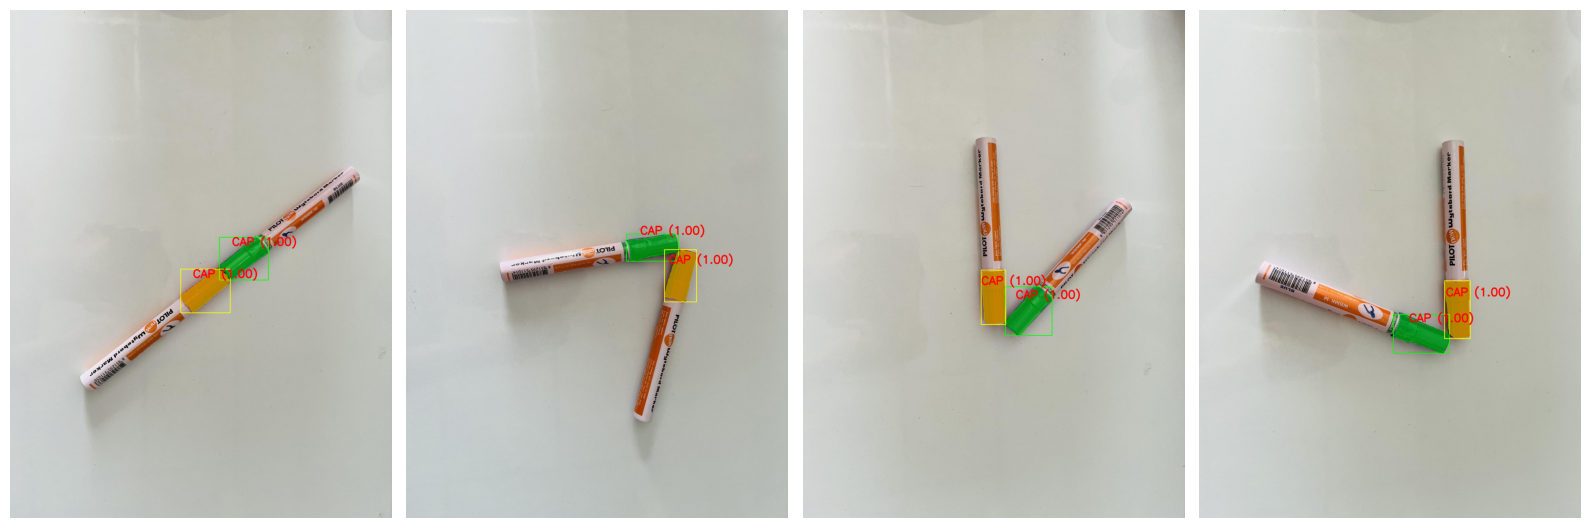

In [ ]:
visualize_maskformer_predictions_final(
    model=model,
    processor=processor,
    dataset=eval_dataset,
    device="cuda",  # or "cpu"
    score_threshold=0.5,
    num_images=4)

In [ ]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 11.0 MB/s eta 0:00:00


In [ ]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 3.0 MB/s eta 0:00:00


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [ ]:
model = model.cpu()
dummy_input = torch.randn(1, 3, 800, 800).cpu()

In [ ]:
onnx_model_path = "maskformerresults/checkpoint-285.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    opset_version=16,
    input_names=["input"],
    output_names=["boxes"],
    dynamic_axes={
        "input": {0: "batch_size", 2: "height", 3: "width"},
        "boxes": {0: "num_boxes"},
    },
    do_constant_folding=True,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

/tmp/ipykernel_1707/1780123457.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0318 07:26:55.943000 1707 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0318 07:26:57.447000 1707 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, al

[torch.onnx] Obtain model graph for `MaskFormerForInstanceSegmentation([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MaskFormerForInstanceSegmentation([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:65: adapter_lookup: Assertion `false`

Applied 316 of general pattern rewrite rules.
ONNX export maskformerresults/checkpoint-285.onnx completed successfully!


In [ ]:
import onnxruntime
import numpy as np
import cv2
import torch
import os
import random

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg"

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (800, 800))
img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
img_input = (img_input - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("maskformerresults/checkpoint-285.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 100, 134), (1, 100, 200, 200), (1, 768, 25, 25), (1, 256, 200, 200), (1, 100, 256)]


In [ ]:
for i, o in enumerate(outputs): print(f"Idx {i}: Max={o.max():.2f}, Min={o.min():.2f}, Shape={o.shape}")

Idx 0: Max=12.85, Min=-13.38, Shape=(1, 100, 134)
Idx 1: Max=13.21, Min=-83.36, Shape=(1, 100, 200, 200)
Idx 2: Max=8.26, Min=-21.59, Shape=(1, 768, 25, 25)
Idx 3: Max=15.91, Min=-12.38, Shape=(1, 256, 200, 200)
Idx 4: Max=4.65, Min=-4.06, Shape=(1, 100, 256)


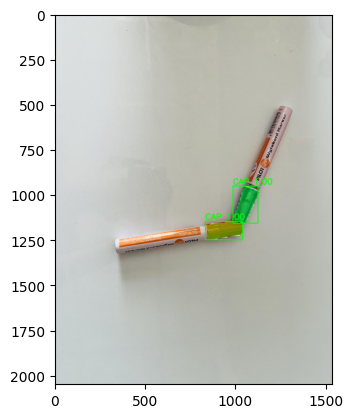

In [ ]:
import cv2
import numpy as np
import os
import random
from matplotlib import pyplot as plt

# Class labels
CLASS_LABELS = ["", "CAP"]

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

def visualize_results(img_orig, outputs, threshold=0.8):
    h, w = img_orig.shape[:2]
    annotated_img = img_orig.copy()

    final_cls_logits = outputs[0][0]   # Shape: (100, num_classes + 1)
    final_mask_logits = outputs[1][0] # Shape: (100, 200, 200)

    # Get probabilities for all 100 queries
    # Query scores are the max probability across the classes (excluding background)
    probs = softmax(final_cls_logits)

    # In Mask2Former, the last column is usually the "Background" class
    scores = np.max(probs[:, :-1], axis=1)
    labels = np.argmax(probs[:, :-1], axis=1)

    keep_indices = np.where(scores > threshold)[0]
    # print(f"Verified Max Score: {np.max(scores):.4f} | Objects to draw: {len(keep_indices)}")

    for idx in keep_indices:
        score = scores[idx]
        label = labels[idx]
        labeltext = CLASS_LABELS[label]

        if label == 0: continue  # Skip drawing; background is already the base layer

        m_logits = final_mask_logits[idx]
        m_prob = sigmoid(m_logits)
        m_resized = cv2.resize(m_prob, (w, h), interpolation=cv2.INTER_CUBIC)
        binary_mask = (m_resized > 0.5).astype(np.uint8)

        if not binary_mask.any(): continue

        color = (0, 255, 0)

        # Apply Mask Overlay
        colored_mask = np.zeros_like(img_orig, dtype=np.uint8)
        colored_mask[binary_mask == 1] = color
        annotated_img = cv2.addWeighted(colored_mask, 0.5, annotated_img, 1, 0)

        # Instead of guessing the box tensor index, derive it from the mask
        y, x = np.where(binary_mask)
        if len(x) > 0 and len(y) > 0:
            x1, y1, x2, y2 = np.min(x), np.min(y), np.max(x), np.max(y)
            cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 3)
            cv2.putText(annotated_img, f"{labeltext} {score:.2f}", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

    return annotated_img

# EXECUTE
result_viz = visualize_results(img, outputs, threshold=0.5)
plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
plt.show()

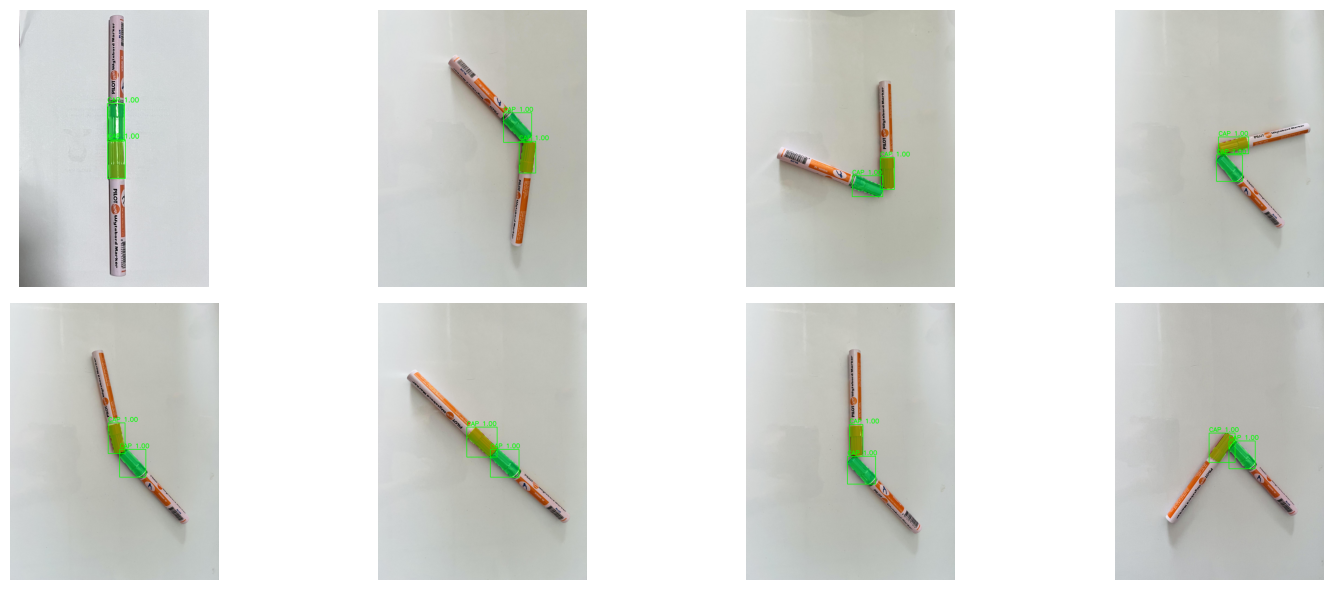

In [ ]:
CONF_THR = 0.5

# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (800, 800))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
    img_input = (img_input - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    result_viz = visualize_results(img, outputs, threshold=CONF_THR)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()